# 01 — Microlensing light curve

Fit a point-mass microlensing event using two parameterizations:

1. **Physical**: `(M, v_rel, D_L, D_S, ...)` — used for forward simulation; degenerate.
2. **Minimal Paczynski**: `(f_S, t_0, y_0, t_E)` — what observers fit.

We then sample the minimal model with NUTS to quantify the posterior.

In [1]:
# Bootstrap: make `lensing` importable when running notebooks/ directly.
import sys
from pathlib import Path
repo = Path.cwd().resolve().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import lensing as gl
# Device-agnostic: prefer MPS (Apple GPU) → CUDA → CPU.
# Pass device="cpu" if you need to force the CPU path (e.g. for
# operators that have no MPS kernel yet, or for reproducibility).
device, dtype = gl.config.setup(seed=42)
print(f"using device: {device}")


/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device: mps


## 1. Simulate from physical parameters

In [2]:
phys = gl.lens.PointMassMicrolens(
    f=7.0, mass=0.3, y0=0.1, vel=200., t0=183., dl=4., ds=8.,
)
t = torch.arange(0., 365., 1.)
sigma = 0.1 * 7.0
clean, mag = gl.data.simulate_lightcurve(phys, t, noise_sigma=sigma, seed=0)
print(f"theta_E = {float(phys.einstein_radius()):.3e} arcsec")
print(f"t_E     = {float(phys.einstein_time()):.2f} days")


theta_E = 5.526e-04 arcsec
t_E     = 19.14 days


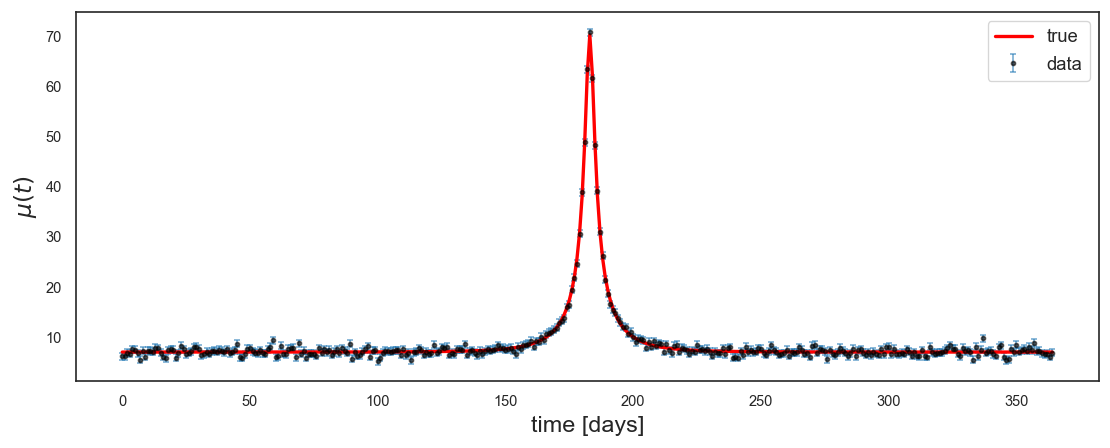

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.errorbar(t, mag, yerr=sigma, fmt='.', color='k',
            ecolor='C0', elinewidth=1, capsize=2, alpha=0.6, label='data')
ax.plot(t, clean, 'r-', lw=2, label='true')
ax.set(xlabel='time [days]', ylabel=r'$\mu(t)$'); ax.legend(); plt.show()


## 2. Fit the minimal Paczynski model

In [4]:
paczy = gl.lens.PaczynskiLightcurve(f=2.0, y0=0.6, t0=114., tE=10.)
loss_fn = gl.inference.ReducedChiSquared(sigma=sigma, n_params=4)
result = gl.inference.fit(
    paczy, t, mag, loss_fn,
    lr=0.1, epochs=4000,
    scheduler=gl.inference.optimize.reduce_lr_on_plateau(),
    lbfgs_polish=True,
)
print(f"final chi2/dof = {result.best_loss:.3f} in {result.duration_s:.1f}s")
for k, v in result.parameters.items():
    print(f"  {k}: {v:.4f}")


final chi2/dof = 0.949 in 0.7s
  f: 7.0340
  y0: 0.0998
  t0: 182.9772
  tE: 18.9358


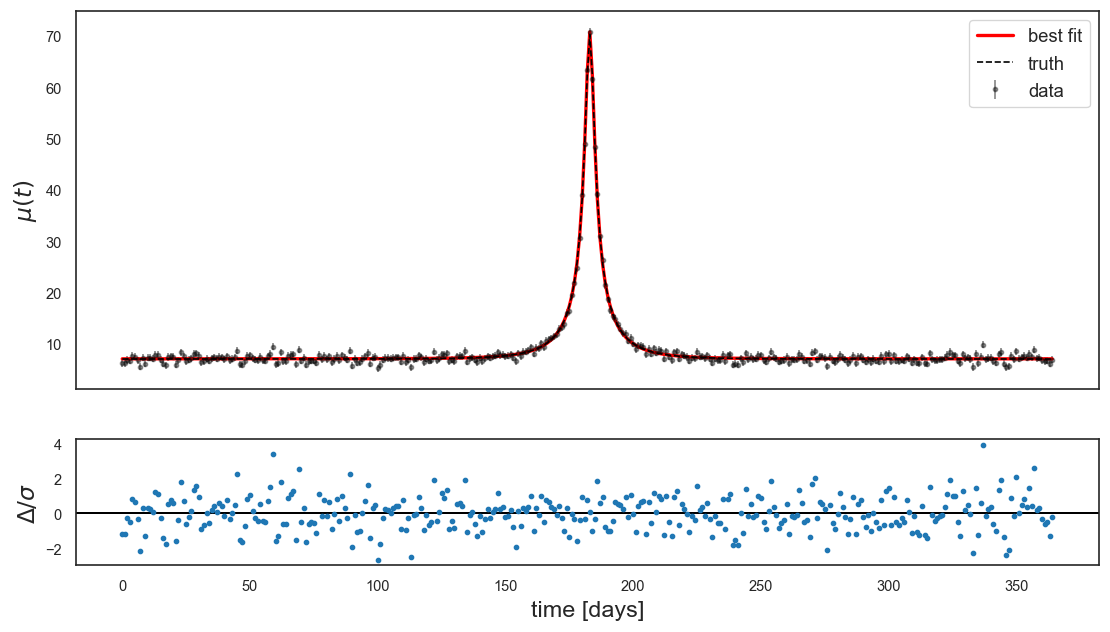

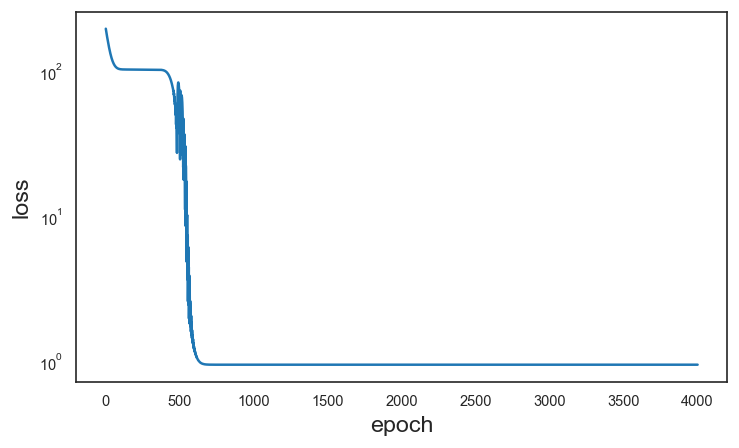

In [5]:
with torch.no_grad():
    fit_lc = paczy(t).numpy()
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={'height_ratios':[3,1]})
axes[0].errorbar(t, mag, yerr=sigma, fmt='.', color='k', alpha=.4, label='data')
axes[0].plot(t, fit_lc, 'r-', lw=2, label='best fit')
axes[0].plot(t, clean, 'k--', lw=1, label='truth')
axes[0].set_ylabel(r'$\mu(t)$'); axes[0].legend()
res = (mag.numpy() - fit_lc) / sigma
axes[1].errorbar(t, res, fmt='.', color='C0'); axes[1].axhline(0, color='k')
axes[1].set(ylabel=r'$\Delta/\sigma$', xlabel='time [days]'); plt.show()

gl.viz.plot_loss_history(result.loss_history); plt.show()


## 3. NUTS posterior (cached)

Set `RUN_NUTS=True` to regenerate the cache (~30 s on CPU).

In [6]:
RUN_NUTS = False
csv = Path('cache/posterior_microlens.csv'); csv.parent.mkdir(exist_ok=True)

df = None
if RUN_NUTS:
    import pyro, pyro.distributions as dist
    def pyro_model(t, mag):
        f  = pyro.sample('f',  dist.Uniform(0.1, 50.))
        t0 = pyro.sample('t0', dist.Uniform(0., 365.))
        y0 = pyro.sample('y0', dist.Uniform(0.01, 1.))
        tE = pyro.sample('tE', dist.Uniform(0.1, 365.))
        pred = gl.lens.PaczynskiLightcurve(f, y0, t0, tE)(t)
        with pyro.plate('data', len(mag)):
            pyro.sample('obs', dist.Normal(pred, sigma), obs=mag)
    df = gl.inference.run_nuts(pyro_model, t, mag,
                              num_samples=2000, warmup_steps=500,
                              save_path=str(csv))
elif csv.exists():
    import pandas as pd
    df = pd.read_csv(csv)
else:
    print("No cached posterior; set RUN_NUTS=True to generate it.")

if df is not None and len(df):
    print(df.describe())


                 f           t0           tE           y0
count  2000.000000  2000.000000  2000.000000  2000.000000
mean      0.273020   183.011913   344.542746     0.010533
std       0.009240     0.055996     0.051841     0.000003
min       0.257469   182.857210   344.399230     0.010529
25%       0.265145   182.974635   344.522580     0.010531
50%       0.272414   183.014090   344.543980     0.010532
75%       0.281428   183.050295   344.574302     0.010535
max       0.289136   183.182190   344.686700     0.010540


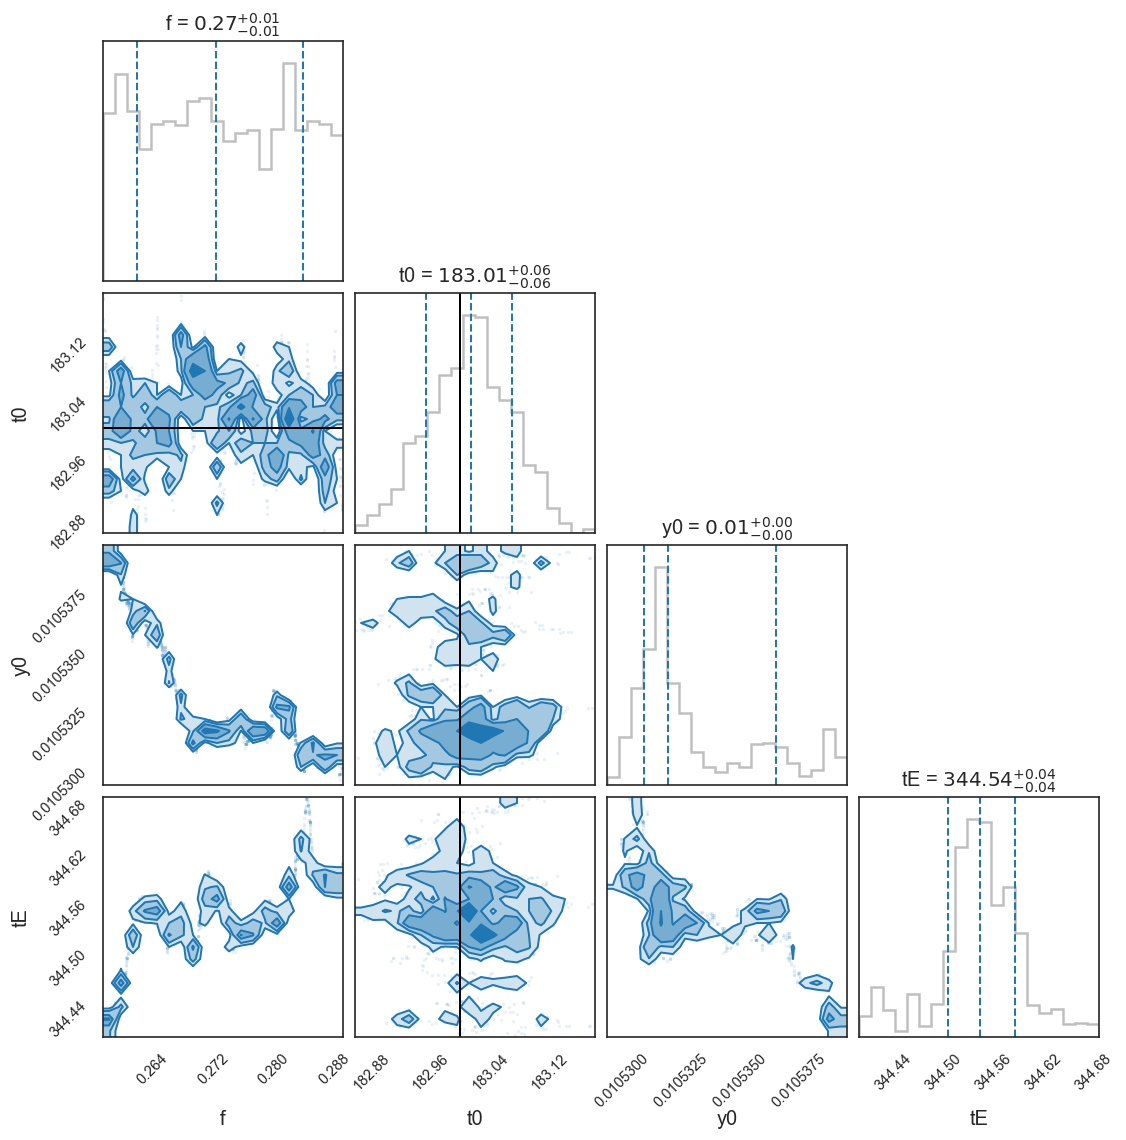

In [7]:
if df is not None and len(df):
    truths = {'f': 7.0, 't0': 183., 'y0': 0.1,
              'tE': float(phys.einstein_time())}
    df_ord = df[['f', 't0', 'y0', 'tE']]
    gl.viz.corner_plot(df_ord, truths=[truths[k] for k in df_ord.columns]); plt.show()
